<a href="https://colab.research.google.com/github/tejas1824/CSL701-Roll_No_Machine-Learning-Lab/blob/main/ML_exp2_CE30.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name:Tejas Sanjiv Mochemadkar
Roll no:C30
Batch:CE02

Aim: To implement a Simple Linear Regression model using Python and predict MPG from Horsepower using OLS.


Objective:


## Objectives
- Understand SLR
- Load/preprocess dataset
- Perform EDA
- Compute OLS coefficients
- Evaluate with SSE, MSE, R²
- Visualize regression and residual plots

## Software Requirements
- Python 3.x
- Jupyter/Colab/VS Code
- Libraries: pandas, numpy, matplotlib, seaborn

## Theory
Linear regression models the relationship between a target continuous variable Y and an input feature vector X using a linear equation:

$$
\hat{y} = w_0 + w_1x_1
$$

In matrix form, including the bias/intercept term $X_0$=1:

$$
\hat{y} = Xw
$$

To find the optimal weight vector wˆ, the Ordinary Least Squares (OLS) method minimizes the Sum of Squared Errors (SSE) between actual target values y and predicted values yˆ:

$$
SSE = \sum_{i=1}^{N}(y_i-\hat{y}_i)^2
= (y-Xw)^T(y-Xw)
$$

                    

Solving for w analytically yields the normal equation:

$$
\hat{w} = (X^T X)^{-1}X^T y
$$

###Note:The inverse XTX-1 exists only if the matrix XTX is non-singular (i.e., its determinant is non-zero).


Import libraries

In [6]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

Load dataset


In [7]:
import pandas as pd
df = pd.read_csv("auto-mpg (3).csv")

Display first five rows

In [8]:
print(df.head())

    mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0        130    3504          12.0          70   
1  15.0          8         350.0        165    3693          11.5          70   
2  18.0          8         318.0        150    3436          11.0          70   
3  16.0          8         304.0        150    3433          12.0          70   
4  17.0          8         302.0        140    3449          10.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  


 Data preprocessing

In [9]:
df = df[['horsepower', 'mpg']]
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df.dropna(inplace=True)

Independent and dependent variables

In [10]:
X = df[['horsepower']]
y = df['mpg']


Train-test split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Linear Regression Model (uses Ordinary Least Squares - OLS)

In [12]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

OLS Coefficients

In [13]:
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: 40.606097600118346
Slope: -0.16259724322918453


 Evaluation Metrics

In [14]:
SSE = np.sum((y_test - y_pred) ** 2)
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
R2 = r2_score(y_test, y_pred)

print("\nEvaluation Metrics")
print("SSE :", SSE)
print("MSE :", MSE)
print("RMSE:", RMSE)
print("R² Score:", R2)



Evaluation Metrics
SSE : 1750.1057327852095
MSE : 22.153237123863413
RMSE: 4.706722545876633
R² Score: 0.5659681822256185


Regression Plot

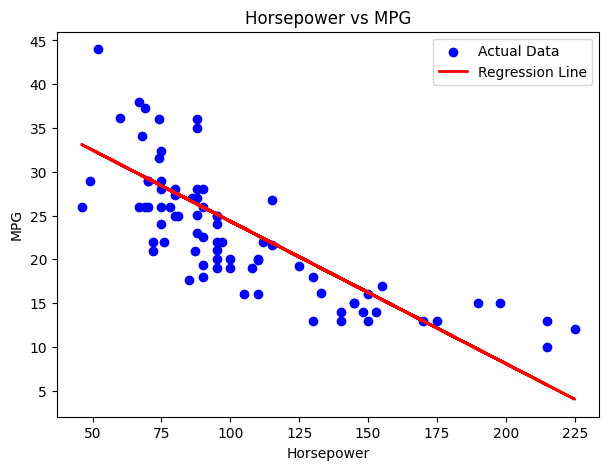

In [15]:
plt.figure(figsize=(7,5))
plt.scatter(X_test, y_test, color='blue', label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Horsepower vs MPG")
plt.legend()
plt.show()

Residual Plot

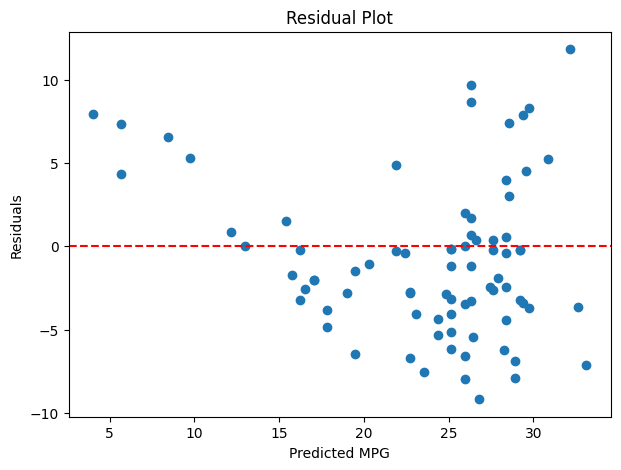

In [16]:
residuals = y_test - y_pred

plt.figure(figsize=(7,5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

Interpretation

In [17]:
print("\nInterpretation:")
if model.coef_[0] < 0:
    print("Horsepower has a negative relationship with MPG.")
else:
    print("Horsepower has a positive relationship with MPG.")

print("The model was built using Ordinary Least Squares (OLS) Linear Regression.")
print("Performance is evaluated using SSE, MSE, RMSE, and R² Score.")


Interpretation:
Horsepower has a negative relationship with MPG.
The model was built using Ordinary Least Squares (OLS) Linear Regression.
Performance is evaluated using SSE, MSE, RMSE, and R² Score.
